# 1. Predictions on PPMI data (m-values)

In [1]:
src_data_path = "/workspace/multi_cohort_harmonized_data.parquet"
import pandas as pd
df_multi_cohort = pd.read_parquet(src_data_path)

In [2]:
df_gse111629 = df_multi_cohort[df_multi_cohort["Cohort"] == "GSE111629"]

In [3]:
del df_multi_cohort

In [4]:
meta_cols = [col for col in df_gse111629.columns if not (col.startswith("cg") or col.startswith("ch"))]
meta_cols

['Sample_Group', 'SEX', 'Age_Group', 'Sample_Name', 'Cohort']

In [5]:
target_var = "Sample_Group"
Y_gse111629 = df_gse111629[target_var]
X_gse111629 = df_gse111629.drop(columns=meta_cols)

Y_gse111629 = Y_gse111629.map({"Control": 0, "PD": 1})

In [6]:
X_gse111629 = X_gse111629.to_numpy(dtype="float32")
Y_gse111629 = Y_gse111629.to_numpy(dtype="float32")

In [7]:
def generate_global_shap_plots(global_shap_exp, dataset_name, top_n=20):
    import matplotlib.pyplot as plt
    import shap
    import numpy as np
    """
    Generates two independent SHAP plots (Bar and Beeswarm) from a global SHAP Explanation.
    Automatically removes the "Sum of remaining features" row by pre-slicing the data.
    Returns the two Matplotlib Figure objects to the caller.
    """
    
    # 1. PRE-SLICE THE EXPLANATION OBJECT
    # Calculate the mean absolute SHAP value (global impact) for every feature
    mean_abs_impact = np.abs(global_shap_exp.values).mean(axis=0)
    
    # Get the indices of the top N features, sorted from highest to lowest impact
    top_indices = np.argsort(mean_abs_impact)[::-1][:top_n]
    
    # Slice the SHAP Explanation object to ONLY contain these exact features
    sliced_exp = global_shap_exp[:, top_indices]
    
    # ==========================================
    # PLOT 1: SHAP Bar Plot (Magnitude)
    # ==========================================
    fig_bar, ax_bar = plt.subplots(figsize=(10, 8))
    plt.sca(ax_bar) 
    
    # Because sliced_exp only contains top_n features, no "Sum of..." row is generated
    shap.plots.bar(sliced_exp, max_display=top_n, show=False)
    
    ax_bar.set_title(f"Global Feature Importance (Mean Absolute Impact) - {dataset_name}", fontsize=14, fontweight='bold', pad=15)
    ax_bar.set_xlabel("mean(|SHAP value|) - Average impact on model output", fontsize=12)
    fig_bar.tight_layout()
    
    # ==========================================
    # PLOT 2: SHAP Beeswarm Plot (Direction)
    # ==========================================
    fig_bee, ax_bee = plt.subplots(figsize=(10, 8))
    plt.sca(ax_bee) 
    
    shap.plots.beeswarm(sliced_exp, max_display=top_n, show=False)
    
    ax_bee.set_title(f"Global Feature Impact (Directionality) - {dataset_name}", fontsize=14, fontweight='bold', pad=15)
    ax_bee.set_xlabel("SHAP value (Impact on prediction: Negative=Control, Positive=PD)", fontsize=12)
    fig_bee.tight_layout()
    
    # Return the clean figure objects back to the caller
    return fig_bar, fig_bee

In [8]:
def plot_roc_pr_auc_cv(mean_fpr, tprs, fold_aucs, mean_recall, precisions_list, fold_pr_aucs, Y_cpu, dataset_name):
    import numpy as np
    import matplotlib.pyplot as plt

    # Create a 1x2 grid with a clean academic aesthetic
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

    # ==========================================
    # PANEL 1: ROC-AUC CURVES
    # ==========================================
    for i in range(10):
        ax1.plot(
            mean_fpr, tprs[i], 
            alpha=0.3, lw=1.5, # Lighter shade for individual folds
            label=f"Fold {i+1} (AUC = {fold_aucs[i]:.3f})"
        )

    # Calculate Mean and Standard Deviation
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0 # Anchor the end
    std_tpr = np.std(tprs, axis=0)
    tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

    # Plot Mean Curve and shaded Std Dev
    ax1.plot(mean_fpr, mean_tpr, color='black', lw=3, label=f"Mean ROC (AUC = {np.mean(fold_aucs):.3f})")
    ax1.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=0.2, label=r"$\pm$ 1 Std. Dev.")
    ax1.plot([0, 1], [0, 1], linestyle='--', lw=2, color='darkred', label="Random Guess")

    ax1.set_xlim([-0.05, 1.05])
    ax1.set_ylim([-0.05, 1.05])
    ax1.set_xlabel('False Positive Rate', fontsize=14)
    ax1.set_ylabel('True Positive Rate', fontsize=14)
    ax1.set_title(f"Receiver Operating Characteristic (10-Fold CV) ({dataset_name})", fontsize=16, fontweight='bold', pad=15)
    ax1.legend(loc="lower right", fontsize=10)
    ax1.grid(True, alpha=0.3)

    # ==========================================
    # PANEL 2: PR-AUC CURVES
    # ==========================================
    # Calculate baseline (proportion of positive cases in the whole dataset)
    baseline = np.sum(Y_cpu) / len(Y_cpu)

    for i in range(10):
        ax2.plot(
            mean_recall, precisions_list[i], 
            alpha=0.3, lw=1.5,
            label=f"Fold {i+1} (PR = {fold_pr_aucs[i]:.3f})"
        )

    # Calculate Mean and Standard Deviation
    mean_precision = np.mean(precisions_list, axis=0)
    std_precision = np.std(precisions_list, axis=0)
    prec_upper = np.minimum(mean_precision + std_precision, 1)
    prec_lower = np.maximum(mean_precision - std_precision, 0)

    # Plot Mean Curve and shaded Std Dev
    ax2.plot(mean_recall, mean_precision, color='black', lw=3, label=f"Mean PR (AUC = {np.mean(fold_pr_aucs):.3f})")
    ax2.fill_between(mean_recall, prec_lower, prec_upper, color='grey', alpha=0.2, label=r"$\pm$ 1 Std. Dev.")
    ax2.plot([0, 1], [baseline, baseline], linestyle='--', lw=2, color='darkred', label=f"Baseline ({baseline:.2f})")

    ax2.set_xlim([-0.05, 1.05])
    ax2.set_ylim([-0.05, 1.05])
    ax2.set_xlabel('Recall (Sensitivity)', fontsize=14)
    ax2.set_ylabel('Precision (PPV)', fontsize=14)
    ax2.set_title(f"Precision-Recall Curve (10-Fold CV) ({dataset_name})", fontsize=16, fontweight='bold', pad=15)
    ax2.legend(loc="lower left", fontsize=10)
    ax2.grid(True, alpha=0.3)

    # Final formatting
    plt.tight_layout()
    plt.show()

In [9]:
def cv_pipeline(X_all, Y_all, dataset_name, feature_names):

    import numpy as np
    import cupy as cp
    import cudf
    import xgboost as xgb
    from cuml.preprocessing import StandardScaler
    from cuml.linear_model import LogisticRegression
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import roc_auc_score, average_precision_score
    from sklearn.metrics import roc_curve, precision_recall_curve
    import shap

    print("--- Initializing 10-Fold GPU Pipeline ---")

    variances = np.var(X_all, axis=0)
    threshold = np.percentile(variances, 25) 
    high_var_mask = variances > threshold
    X_high_var = X_all[:, high_var_mask]
    print(f"Reduced features from {X_all.shape[1]} to {X_high_var.shape[1]} based on variance.")
    selected_feature_names_global = feature_names[high_var_mask]
    # Assuming X_mvalues is your pandas/cudf dataframe of harmonized M-values
    # Assuming Y_labels is your pandas/cudf series of PD_Status (0 = Control, 1 = PD)

    # Convert data to CuPy arrays to ensure it stays in GPU memory (VRAM)
    X_gpu = cp.array(X_high_var, dtype=cp.float32)
    Y_gpu = cp.array(Y_all, dtype=cp.float32)

    # Move Y to CPU just for the StratifiedKFold splitter (sklearn requires CPU labels)
    Y_cpu = cp.asnumpy(Y_gpu)

    # Initialize the 10-Fold Stratified Splitter
    # Stratified ensures the ratio of PD to Controls stays exactly the same in every fold
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    # Metrics tracking
    fold_aucs = []
    fold_pr_aucs = []
    selected_feature_counts = []

    mean_fpr = np.linspace(0, 1, 100)
    mean_recall = np.linspace(0, 1, 100)

    global_shap_matrix = np.zeros((len(Y_cpu), X_high_var.shape[1]))
    global_data_matrix = np.zeros((len(Y_cpu), X_high_var.shape[1]))

    tprs = []
    precisions_list = []

    fold = 1
    for train_idx, val_idx in skf.split(np.zeros(len(Y_cpu)), Y_cpu):
        print(f"\n--- Processing Fold {fold}/10 ---")
        
        # 1. SPLIT DATA (Still on GPU)
        X_train, X_val = X_gpu[train_idx], X_gpu[val_idx]
        Y_train, Y_val = Y_gpu[train_idx], Y_gpu[val_idx]
        
        # 2. SCALING (Fitted ONLY on training data)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val) # Transform validation data using train math
        
        # 3. FEATURE SELECTION: Elastic Net via Logistic Regression
        # l1_ratio: 0 = L2 (Ridge), 1 = L1 (Lasso), 0.5 = pure Elastic Net
        # solver='qn' (Quasi-Newton) is required for elasticnet penalty in cuml
        enet_selector = LogisticRegression(
            penalty='elasticnet', 
            l1_ratio=0.5, 
            C=0.1, # Inverse of regularization strength; tweak this to select more/fewer features
            solver='qn', 
            max_iter=1000
        )
        enet_selector.fit(X_train_scaled, Y_train)
        
        # Extract coefficients and create a boolean mask for non-zero features
        coefficients = enet_selector.coef_
        
        # cuml coef_ shape can be (1, n_features) or (n_features,). Ensure flat.
        if len(coefficients.shape) > 1:
            coefficients = coefficients[0]
            
        feature_mask = (cp.abs(coefficients) > 0)
        num_selected = int(cp.sum(feature_mask))
        selected_feature_counts.append(num_selected)
        print(f"Features selected by Elastic Net: {num_selected}")

        # Fallback: If Elastic Net shrinks everything to 0, use all features to prevent crash
        if num_selected == 0:
            print("Warning: Elastic Net eliminated all features. Bypassing selection for this fold.")
            feature_mask = cp.ones(X_train_scaled.shape[1], dtype=bool)
        
        selected_feature_names = selected_feature_names_global[feature_mask.get()]
            
        # Apply the mask to both Train and Val
        X_train_selected = X_train_scaled[:, feature_mask]
        X_val_selected = X_val_scaled[:, feature_mask]
        
        # 4. XGBOOST TRAINING
        # tree_method='hist' and device='cuda' force XGBoost to run blazingly fast on the GPU
        xgb_model = xgb.XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            tree_method='hist',
            device='cuda',
            eval_metric='logloss',
            random_state=42
        )
        
        # XGBoost handles cupy arrays natively in modern versions
        xgb_model.fit(X_train_selected, Y_train)
        
        # 5. PREDICTION & METRICS
        # Predict probabilities for the validation fold
        val_probs = xgb_model.predict_proba(X_val_selected)[:, 1]
        
        # Move metrics to CPU for sklearn metric calculation
        Y_val_cpu = cp.asnumpy(Y_val)
        val_probs_cpu = cp.asnumpy(val_probs)
        
        auc = roc_auc_score(Y_val_cpu, val_probs_cpu)
        pr_auc = average_precision_score(Y_val_cpu, val_probs_cpu)

        # --- ROC Curve Interpolation ---
        fpr, tpr, _ = roc_curve(Y_val_cpu, val_probs_cpu)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0 # Anchor the start
        tprs.append(interp_tpr)
        
        # --- PR Curve Interpolation ---
        precision, recall, _ = precision_recall_curve(Y_val_cpu, val_probs_cpu)
        # PR arrays are returned in decreasing order of recall; reverse them for np.interp
        interp_prec = np.interp(mean_recall, recall[::-1], precision[::-1])
        precisions_list.append(interp_prec)        
        
        fold_aucs.append(auc)
        fold_pr_aucs.append(pr_auc)

        # --- SHAP CALCULATIONS ---
        explainer = shap.TreeExplainer(xgb_model)
        selected_df = pd.DataFrame(X_val_selected.get(), columns=selected_feature_names)
        
        # Extract the raw NumPy matrix of SHAP values for this fold
        raw_shap_values = explainer.shap_values(selected_df)
        
        # 2. THE COORDINATE MAPPING
        # Convert feature mask to CPU to act as our column indices
        col_indices = cp.asnumpy(feature_mask)
        
        # Map the values into the global matrix using np.ix_ to broadcast rows and columns
        global_shap_matrix[np.ix_(val_idx, col_indices)] = raw_shap_values
        global_data_matrix[np.ix_(val_idx, col_indices)] = cp.asnumpy(X_val_selected)
        
        print(f"Fold {fold} ROC-AUC: {auc:.4f} | PR-AUC: {pr_auc:.4f}")
        fold += 1

    # --- Final Results ---
    print("\n================ 10-FOLD CV RESULTS ================")
    print(f"Mean ROC-AUC: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
    print(f"Mean PR-AUC:  {np.mean(fold_pr_aucs):.4f} ± {np.std(fold_pr_aucs):.4f}")
    print(f"Average Features Selected per fold: {np.mean(selected_feature_counts):.1f}")

    plot_roc_pr_auc_cv(mean_fpr, tprs, fold_aucs, mean_recall, precisions_list, fold_pr_aucs, Y_cpu, dataset_name)

    global_explanation = shap.Explanation(
        values=global_shap_matrix,
        data=global_data_matrix,
        feature_names=selected_feature_names_global
    )
    return global_explanation

In [10]:
feature_names = df_gse111629.drop(columns=meta_cols).columns.to_numpy()

In [11]:
# %conda install shap -y

/opt/conda/envs/rapids-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- Initializing 10-Fold GPU Pipeline ---
Reduced features from 388296 to 291222 based on variance.

--- Processing Fold 1/10 ---
Features selected by Elastic Net: 490
Fold 1 ROC-AUC: 0.7630 | PR-AUC: 0.8259

--- Processing Fold 2/10 ---
Features selected by Elastic Net: 454
Fold 2 ROC-AUC: 0.7335 | PR-AUC: 0.7833

--- Processing Fold 3/10 ---
Features selected by Elastic Net: 437
Fold 3 ROC-AUC: 0.6536 | PR-AUC: 0.6869

--- Processing Fold 4/10 ---
Features selected by Elastic Net: 445
Fold 4 ROC-AUC: 0.6690 | PR-AUC: 0.7113

--- Processing Fold 5/10 ---
Features selected by Elastic Net: 532
Fold 5 ROC-AUC: 0.8387 | PR-AUC: 0.8886

--- Processing Fold 6/10 ---
Features selected by Elastic Net: 463
Fold 6 ROC-AUC: 0.7232 | PR-AUC: 0.7880

--- Processing Fold 7/10 ---
Features selected by Elastic Net: 450
Fold 7 ROC-AUC: 0.7000 | PR-AUC: 0.7704

--- Processing Fold 8/10 ---
Features selected by Elastic Net: 462
Fold 8 ROC-AUC: 0.8014 | PR-AUC: 0.8594

--- Processing Fold 9/10 ---
Featur

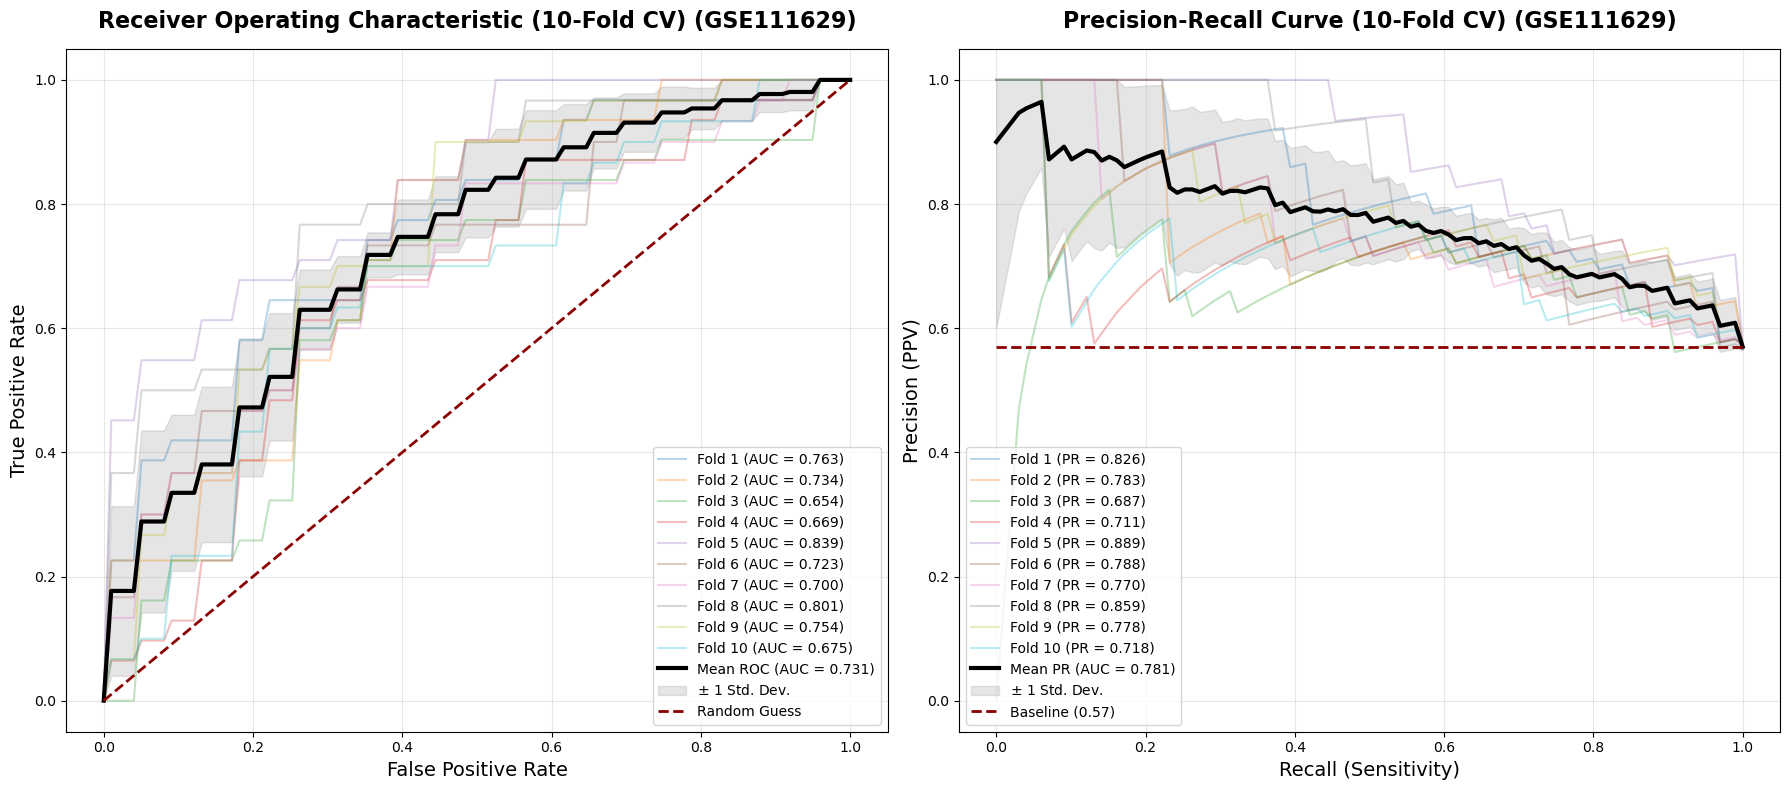

In [12]:
global_shap_explanation = cv_pipeline(X_gse111629, Y_gse111629, "GSE111629", feature_names)

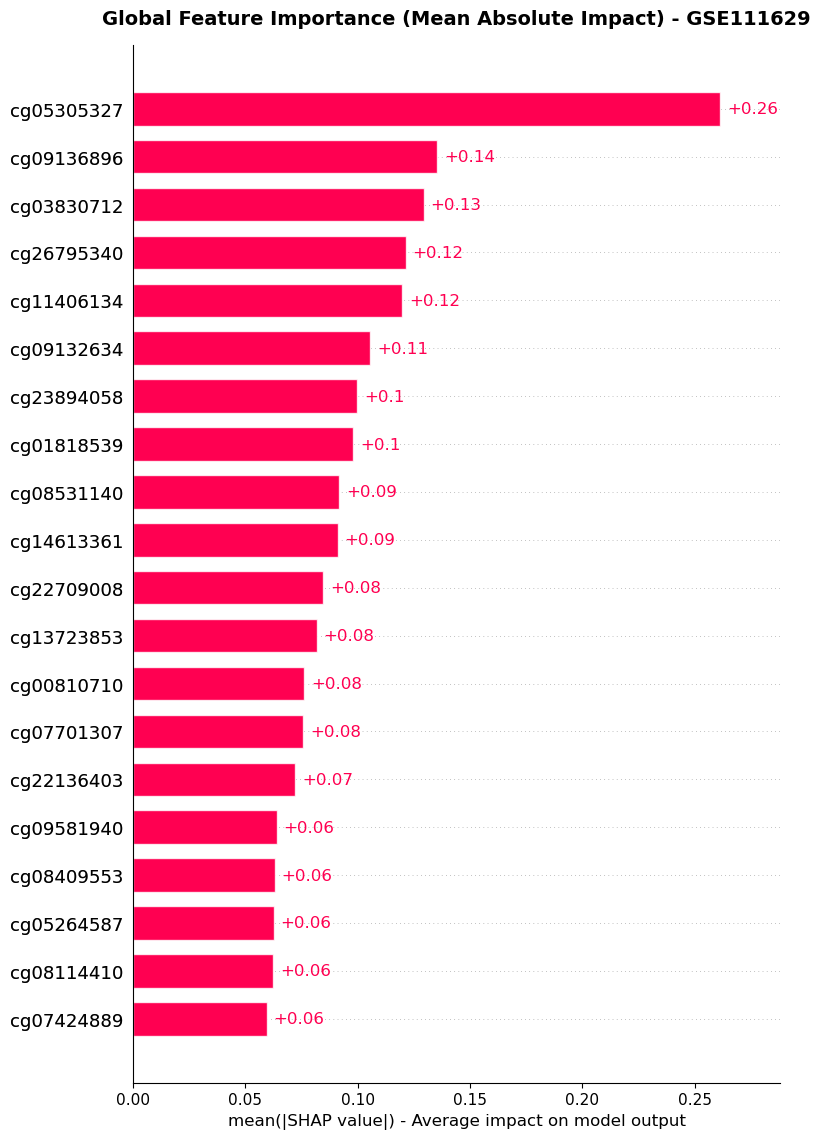

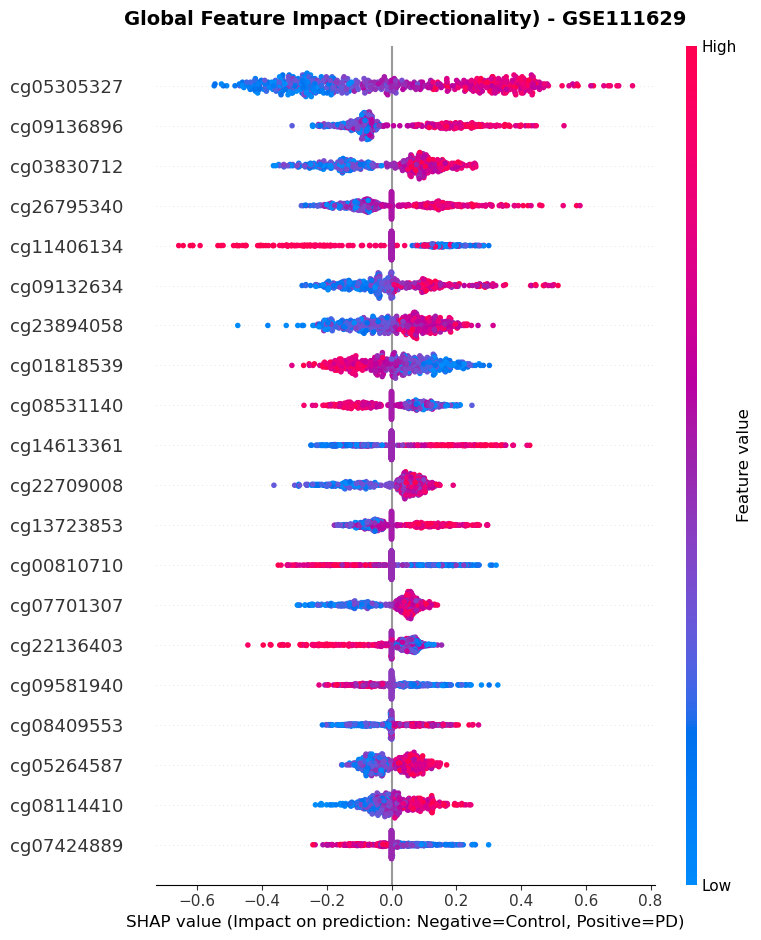

In [13]:
fig_bar, fig_bee = generate_global_shap_plots(global_shap_explanation, "GSE111629")

In [14]:
# %conda install bioconda::gseapy

In [15]:
# %conda install conda-forge::seaborn

--- 1. Extracting Top Features from SHAP ---
--- 2. Loading the EPIC Manifest ---
--- 3. Applying Promoter Filter ---
Filtered down to 179 CpG sites located in active promoter regions.
--- 4. Extracting Unique Gene Targets ---
Final Input: 208 unique regulatory genes for pathway enrichment.
--- 5. Functional Enrichment (Chunked API Calls) ---
Querying Enrichr chunk 1/3: ['GO_Biological_Process_2026', 'KEGG_2021_Human', 'Reactome_Pathways_2024', 'GO_Molecular_Function_2026']...
Querying Enrichr chunk 2/3: ['WikiPathways_2024_Human', 'Elsevier_Pathway_Collection', 'SynGO_2024']...
Querying Enrichr chunk 3/3: ['ENCODE_TF_ChIP-seq_2015', 'TRANSFAC_and_JASPAR_PWMs', 'TRRUST_Transcription_Factors_2019']...
--- 6. Visualization ---

Found 36 significant pathways!


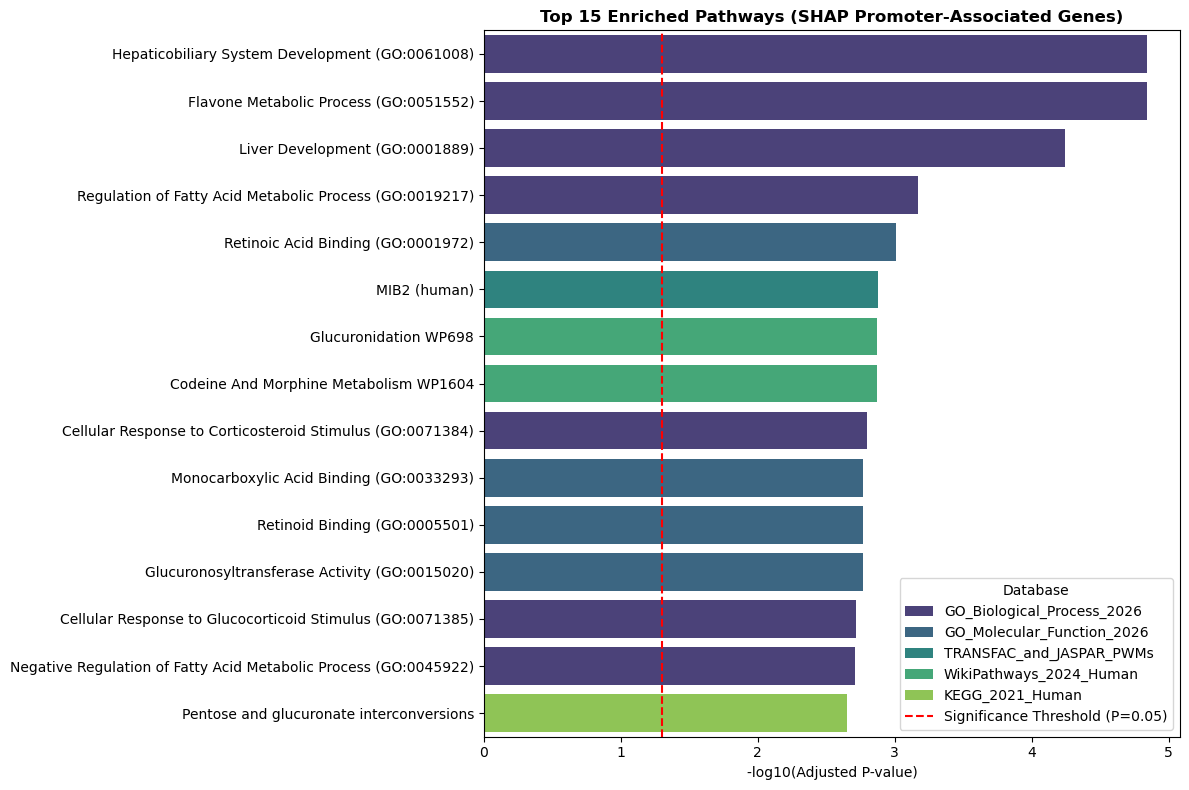

In [ ]:
import pandas as pd
import numpy as np
import gseapy as gp
import matplotlib.pyplot as plt
import seaborn as sns
import time # Required for API rate limiting

print("--- 1. Extracting Top Features from SHAP ---")
# FIXED: Extract raw math array from the object (.values) and column names (.feature_names)
shap_importances = np.abs(global_shap_explanation.values).mean(axis=0)

shap_df = pd.DataFrame({
    'CpG': global_shap_explanation.feature_names,
    'SHAP_Importance': shap_importances
}).sort_values('SHAP_Importance', ascending=False)

top_cpgs = shap_df.head(500)

print("--- 2. Loading the 450k Manifest ---")
# UPDATE THIS PATH to your local 450k manifest CSV
manifest_path = '/workspace/infinium-450k-manifest.csv' 

manifest = pd.read_csv(
    manifest_path, 
    skiprows=7, # Double check your CSV, sometimes Illumina headers end at row 7 or 8
    usecols=['Name', 'CHR', 'MAPINFO', 'UCSC_RefGene_Name', 'UCSC_RefGene_Group'],
    dtype=str,
    encoding='utf-8'
)

# Merge our top SHAP features with the genomic annotations
mapped_cpgs = pd.merge(top_cpgs, manifest, left_on='CpG', right_on='Name', how='left')

print("--- 3. Applying Promoter Filter ---")
# Drop probes that don't map to a known gene at all
mapped_cpgs = mapped_cpgs.dropna(subset=['UCSC_RefGene_Group', 'UCSC_RefGene_Name'])

# Define the regions that actively control gene expression
promoter_regions = ['TSS1500', 'TSS200', "5'UTR", '1stExon']
pattern = '|'.join(promoter_regions)

# Filter: Keep row ONLY if the RefGene_Group contains one of the promoter strings
promoter_cpgs = mapped_cpgs[mapped_cpgs['UCSC_RefGene_Group'].str.contains(pattern, na=False)]

print(f"Filtered down to {len(promoter_cpgs)} CpG sites located in active promoter regions.")

print("--- 4. Extracting Unique Gene Targets ---")
genes_raw = promoter_cpgs['UCSC_RefGene_Name']

# Split semicolons (e.g. "GENE1;GENE2"), flatten the list, and remove duplicates
gene_list = genes_raw.str.split(';').explode().unique().tolist()
gene_list = [g for g in gene_list if g.strip() != '']

print(f"Final Input: {len(gene_list)} unique regulatory genes for pathway enrichment.")

print("--- 5. Functional Enrichment (Chunked API Calls) ---")
# FIXED: Split the massive database list into manageable chunks to prevent API timeouts
database_chunks = [
    ['GO_Biological_Process_2026', 'KEGG_2021_Human', 'Reactome_Pathways_2024', 'GO_Molecular_Function_2026'],
    ['WikiPathways_2024_Human', 'Elsevier_Pathway_Collection', 'SynGO_2024'],
    ['ENCODE_TF_ChIP-seq_2015', 'TRANSFAC_and_JASPAR_PWMs', 'TRRUST_Transcription_Factors_2019']
]

all_results = []

for i, db_chunk in enumerate(database_chunks):
    print(f"Querying Enrichr chunk {i+1}/{len(database_chunks)}: {db_chunk}...")
    try:
        res = gp.enrichr(
            gene_list=gene_list,
            gene_sets=db_chunk,
            organism='human',
            outdir=None 
        )
        all_results.append(res.results)
        time.sleep(3) # Be polite to the API server to prevent getting blocked
    except Exception as e:
        print(f"Warning: Chunk {i+1} failed with error: {e}")

# Combine all the chunked results into one master dataframe
if all_results:
    res_df = pd.concat(all_results, ignore_index=True)
else:
    res_df = pd.DataFrame() # Empty fallback

print("--- 6. Visualization ---")
if not res_df.empty:
    # Filter for statistically significant pathways
    significant_pathways = res_df[res_df['Adjusted P-value'] < 0.05].sort_values('Adjusted P-value')

    if significant_pathways.empty:
        print("\nNo pathways reached statistical significance (Adj. P < 0.05).")
    else:
        print(f"\nFound {len(significant_pathways)} significant pathways!")
        
        plt.figure(figsize=(12, 8))
        
        # Plot top 15
        top_plot = significant_pathways.head(15).copy()
        top_plot['-log10(Adj. P)'] = -np.log10(top_plot['Adjusted P-value'])
        
        sns.barplot(
            data=top_plot,
            x='-log10(Adj. P)',
            y='Term',
            hue='Gene_set',
            dodge=False,
            palette='viridis'
        )
        
        plt.title('Top 15 Enriched Pathways (SHAP Promoter-Associated Genes)', fontweight='bold')
        plt.xlabel('-log10(Adjusted P-value)')
        plt.ylabel('')
        plt.axvline(-np.log10(0.05), color='red', linestyle='--', label='Significance Threshold (P=0.05)')
        plt.legend(title='Database', loc='lower right')
        plt.tight_layout()
        plt.savefig('shap_promoter_pathway_enrichment.pdf', format='pdf', bbox_inches='tight')
        plt.show()
        
        # Save results
        significant_pathways.to_csv('enrichment_results_significant.csv', index=False)

# Always save the mapping so you know exactly which CpGs mapped to which genes
promoter_cpgs.to_csv('top_promoter_cpgs_annotated.csv', index=False)

Calculating SHAP directions...
Aggregating metrics to the gene level...
Calculating pathway-level SHAP metrics...
Generating visualization...


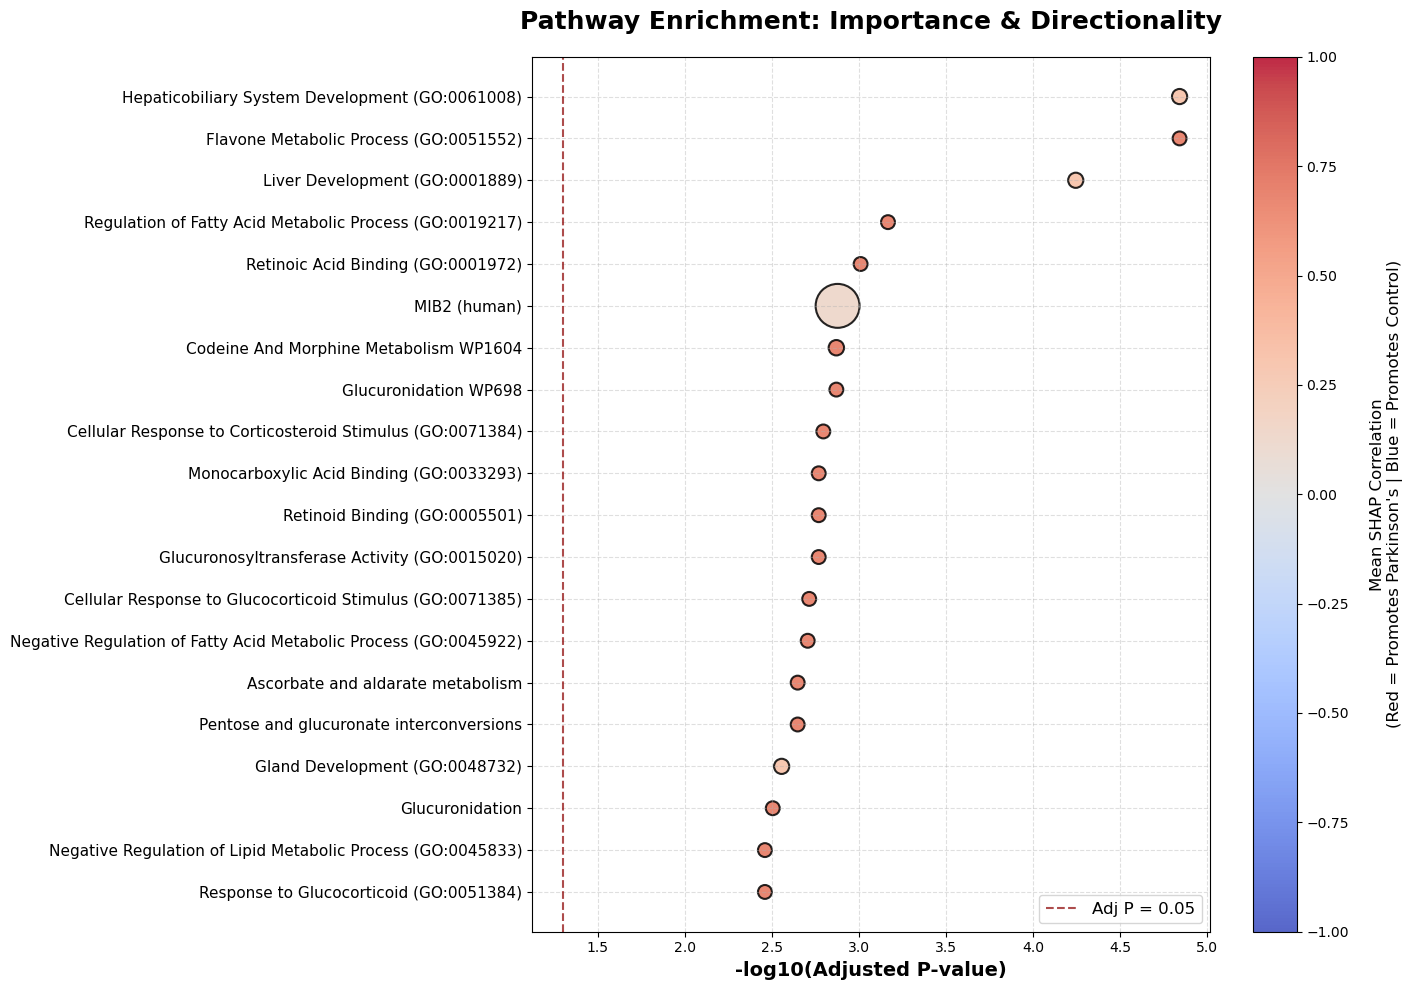

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# --- 1. Calculate SHAP Direction & Importance per CpG ---
print("Calculating SHAP directions...")

# Extract the math matrices directly from the global Explanation object
shap_matrix = global_shap_explanation.values
data_matrix = global_shap_explanation.data
feature_names = global_shap_explanation.feature_names

cpg_stats = []
for i, cpg in enumerate(feature_names):
    importance = np.abs(shap_matrix[:, i]).mean()
    
    # Slice the arrays using the column index 'i'
    feature_vals = data_matrix[:, i] 
    shap_vals = shap_matrix[:, i]
    
    # Safety fix: Prevent division-by-zero errors in Pearson calculation
    if np.std(feature_vals) <= 1e-8 or np.std(shap_vals) <= 1e-8:
        correlation = 0.0
    else:
        correlation, _ = pearsonr(feature_vals, shap_vals)
        
    cpg_stats.append({
        'CpG': cpg,
        'SHAP_Importance': importance,
        'SHAP_Correlation': correlation
    })

cpg_df = pd.DataFrame(cpg_stats)

# --- 2. Map CpGs to Genes and Aggregate ---
print("Aggregating metrics to the gene level...")

# Use 'promoter_cpgs' from the annotation script to ensure we only look at regulatory regions
mapped_stats = pd.merge(cpg_df, promoter_cpgs[['CpG', 'UCSC_RefGene_Name']], on='CpG', how='inner')

# Clean up genes (split semicolons for multi-mapped probes)
mapped_stats = mapped_stats.dropna(subset=['UCSC_RefGene_Name'])
mapped_stats['UCSC_RefGene_Name'] = mapped_stats['UCSC_RefGene_Name'].str.split(';')
mapped_stats = mapped_stats.explode('UCSC_RefGene_Name')
mapped_stats['Gene'] = mapped_stats['UCSC_RefGene_Name'].str.strip()

# Drop any empty strings that might have resulted from the split
mapped_stats = mapped_stats[mapped_stats['Gene'] != '']

# Aggregate SHAP Importance (Sum) and Direction (Mean) per Gene
gene_stats = mapped_stats.groupby('Gene').agg({
    'SHAP_Importance': 'sum',
    'SHAP_Correlation': 'mean' 
}).reset_index()

# Create dictionaries for rapid lookup in the next step
gene_importance_dict = dict(zip(gene_stats['Gene'], gene_stats['SHAP_Importance']))
gene_direction_dict = dict(zip(gene_stats['Gene'], gene_stats['SHAP_Correlation']))

# --- 3. Process Enrichr Results ---
print("Calculating pathway-level SHAP metrics...")

# Use 'res_df' from the chunked Enrichr script
sig_pathways = res_df[res_df['Adjusted P-value'] < 0.05].copy()

if sig_pathways.empty:
    raise ValueError("No significant pathways found to plot. Try relaxing the P-value to 0.10 or review feature selection.")

pathway_data = []
for index, row in sig_pathways.iterrows():
    # Enrichr returns overlapping genes as a string separated by semicolons
    overlap_genes = row['Genes'].split(';') 
    
    # Calculate Pathway SHAP Importance and Direction
    p_importances = [gene_importance_dict.get(g, 0) for g in overlap_genes]
    p_directions = [gene_direction_dict.get(g, 0) for g in overlap_genes]
    
    pathway_data.append({
        'Term': row['Term'],
        'Database': row['Gene_set'],
        '-log10(Adj.P)': -np.log10(row['Adjusted P-value']),
        'Pathway_Importance': np.mean(p_importances) if p_importances else 0,
        'Pathway_Direction': np.mean(p_directions) if p_directions else 0,
        'Gene_Count': len(overlap_genes)
    })

plot_df = pd.DataFrame(pathway_data)

# Sort by significance and take the top 20 to avoid overcrowding the plot
plot_df = plot_df.sort_values('-log10(Adj.P)', ascending=False).head(20)

# --- 4. Generate the Advanced Bubble Plot ---
print("Generating visualization...")
plt.figure(figsize=(14, 10))

# Normalize bubble sizes so they always render perfectly regardless of SHAP scale
min_bubble = 100
max_bubble = 1000
importance_norm = (plot_df['Pathway_Importance'] - plot_df['Pathway_Importance'].min()) / \
                  (plot_df['Pathway_Importance'].max() - plot_df['Pathway_Importance'].min() + 1e-8)
dynamic_sizes = importance_norm * (max_bubble - min_bubble) + min_bubble

# Create the scatter plot
scatter = plt.scatter(
    x=plot_df['-log10(Adj.P)'], 
    y=plot_df['Term'],
    s=dynamic_sizes, 
    c=plot_df['Pathway_Direction'], 
    cmap='coolwarm',       
    edgecolors='black', 
    linewidth=1.5, 
    alpha=0.85,
    vmin=-1, vmax=1      
)

# Formatting
plt.title('Pathway Enrichment: Importance & Directionality', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('-log10(Adjusted P-value)', fontsize=14, fontweight='bold')
plt.ylabel('', fontsize=14)

# Colorbar for Direction
cbar = plt.colorbar(scatter)
cbar.set_label('Mean SHAP Correlation\n(Red = Promotes Parkinson\'s | Blue = Promotes Control)', fontsize=12, labelpad=15)
cbar.ax.tick_params(labelsize=10)

# Add a significance threshold line
plt.axvline(-np.log10(0.05), color='darkred', linestyle='--', alpha=0.7, label='Adj P = 0.05')

# Clean up the Y-axis labels
plt.gca().invert_yaxis() 
plt.yticks(fontsize=11)
plt.grid(True, axis='both', linestyle='--', alpha=0.4)
plt.legend(loc='lower right', fontsize=12)

plt.tight_layout()
plt.savefig('shap_pathway_bubble_plot.pdf', format='pdf', bbox_inches='tight')
plt.show()